In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [119]:
df = pd.read_excel('/content/Copy of Ask A Manager Salary Survey 2021 (Responses).xlsx')

In [120]:
df.head()

,Timestamp,How old are you?,What industry do you work in?,Job title,"If your job title needs additional context, please clarify here:","What is your annual salary? (You'll indicate the currency in a later question. If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.)","How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.",Please indicate the currency,"If ""Other,"" please indicate the currency here:","If your income needs additional context, please provide it here:",What country do you work in?,"If you're in the U.S., what state do you work in?",What city do you work in?,How many years of professional work experience do you have overall?,How many years of professional work experience do you have in your field?,What is your highest level of education completed?,What is your gender?,What is your race? (Choose all that apply.)
0,2021-04-27 11:02:09.743,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,55000,0.0,USD,NaN,NaN,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,2021-04-27 11:02:21.562,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,54600,4000.0,GBP,NaN,NaN,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,2021-04-27 11:02:38.125,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,34000,NaN,USD,NaN,NaN,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,2021-04-27 11:02:40.643,25-34,Nonprofits,Program Manager,NaN,62000,3000.0,USD,NaN,NaN,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,2021-04-27 11:02:41.793,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,60000,7000.0,USD,NaN,NaN,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28225 entries, 0 to 28224
Data columns (total 18 columns):
 #   Column                                                                                                                                                                                                                                Non-Null Count  Dtype         
---  ------                                                                                                                                                                                                                                --------------  -----         
 0   Timestamp                                                                                                                                                                                                                             28225 non-null  datetime64[ns]
 1   How old are you?                                                                        

In [122]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['Timestamp'].dt.year.value_counts().sort_index()

,count
Timestamp,
2021,27597
2022,325
2023,79
2024,103
2025,83
2026,38


In [123]:
#The supplied workbook contains 28,225 records, including responses dated from 2021 to 2026.
#Since the project concerns the Ask A Manager Salary Survey 2021,
#responses outside 2021 were excluded from the analysis to maintain consistency with the stated dataset scope.
df = df[df['Timestamp'].dt.year == 2021].copy()

print("Rows after restricting to 2021:", len(df))

Rows after restricting to 2021: 27597


In [124]:
#Renaming the columns
df = df.rename(columns={
    'How old are you?': 'age',
    'What industry do you work in?': 'industry',
    'Job title': 'job_title',
    'If your job title needs additional context, please clarify here:': 'Additional Job Context',
    "What is your annual salary? (You'll indicate the currency in a later question. If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.)": 'salary',
    'How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.': 'additional_compensation',
    'Please indicate the currency': 'currency',
    'If "Other," please indicate the currency here: ': 'Other Currency',
    'If your income needs additional context, please provide it here:': 'Additional Income Context',
    'What country do you work in?': 'country',
    "If you're in the U.S., what state do you work in?": 'state',
    'What city do you work in?': 'city',
    'How many years of professional work experience do you have overall?': 'overall_experience',
    'How many years of professional work experience do you have in your field?': 'field_experience',
    'What is your highest level of education completed?': 'education',
    'What is your gender?': 'gender',
    'What is your race? (Choose all that apply.)': 'race'
})

In [125]:
#Result of renaming the columns
df.columns

Index(['Timestamp', 'age', 'industry', 'job_title', 'Additional Job Context',
       'salary', 'additional_compensation', 'currency', 'Other Currency',
       'Additional Income Context', 'country', 'state', 'city',
       'overall_experience', 'field_experience', 'education', 'gender',
       'race'],
      dtype='object')

In [126]:
3.1# Convert all column names to title case for consistency
df.columns = [col.replace('_', ' ').title() for col in df.columns]
display(df.columns)

Index(['Timestamp', 'Age', 'Industry', 'Job Title', 'Additional Job Context',
       'Salary', 'Additional Compensation', 'Currency', 'Other Currency',
       'Additional Income Context', 'Country', 'State', 'City',
       'Overall Experience', 'Field Experience', 'Education', 'Gender',
       'Race'],
      dtype='object')

In [127]:
df['Education'].unique()

array(["Master's degree", 'College degree', 'PhD', nan, 'Some college',
       'High School', 'Professional degree (MD, JD, etc.)'], dtype=object)

In [128]:
#Replacing
df['Education'] = df['Education'].replace('Professional degree (MD, JD, etc.)', 'Professional degree')
# Also apply the update to usd_df to keep it in sync
if 'usd_df' in globals():
    usd_df['Education'] = usd_df['Education'].replace('Professional degree (MD, JD, etc.)', 'Professional degree')

print(df['Education'].unique())

["Master's degree" 'College degree' 'PhD' nan 'Some college' 'High School'
 'Professional degree']


In [129]:
#Fill
df['Education'] = df['Education'].fillna('None')
# Keep usd_df in sync if it is active
if 'usd_df' in globals():
    usd_df['Education'] = usd_df['Education'].fillna('None')

print(df['Education'].unique())

["Master's degree" 'College degree' 'PhD' 'None' 'Some college'
 'High School' 'Professional degree']


In [130]:
df['Salary'] = (
    df['Salary']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.strip()
)
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')

In [131]:
df['Salary'].describe()

,Salary
count,2.759700e+04
mean,1.434539e+05
std,5.405021e+06
min,0.000000e+00
25%,5.400000e+04
50%,7.521200e+04
75%,1.100000e+05
max,8.700000e+08


In [132]:
#3.2
#Creating another column for country
df['Country Clean'] = (
    df['Country']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [133]:
#Correcting the spellings of the Countries
us_variants = [
    'usa',
    'us',
    'u.s.',
    'u.s.a.',
    'united states',
    'united states of america'
]
uk_variants = [
    'uk',
    'u.k.',
    'united kingdom'
]

df.loc[df['Country Clean'].isin(us_variants), 'Country Clean'] = 'United States'
df.loc[df['Country Clean'].isin(uk_variants), 'Country Clean'] = 'United Kingdom'
df.loc[df['Country Clean'].eq('canada'), 'Country Clean'] = 'Canada'

In [134]:
df['Country Clean'].value_counts().head(15)

,count
Country Clean,
United States,22645
Canada,1655
United Kingdom,1318
australia,382
germany,190
england,168
ireland,124
new zealand,121
france,66


In [135]:
df['Country Clean'] = df['Country Clean'].str.title()
display(df['Country Clean'].value_counts().head(15))

,count
Country Clean,
United States,22645
Canada,1655
United Kingdom,1318
Australia,382
Germany,190
England,168
Ireland,124
New Zealand,121
France,66


In [136]:
#3.3 Converting other currency to USD
df['Currency'].value_counts()

,count
Currency,
USD,23007
CAD,1649
GBP,1568
EUR,622
AUD/NZD,495
Other,142
CHF,37
SEK,37
JPY,23


In [137]:
usd_df = df[df['Currency'] == 'USD'].copy()

print(len(usd_df))

23007


In [138]:
#3.4 Correcting the age column
experience_map = {
    '1 year or less': 0.5,
    '2 - 4 years': 3,
    '5-7 years': 6,
    '8 - 10 years': 9,
    '11 - 20 years': 15.5,
    '21 - 30 years': 25.5,
    '31 - 40 years': 35.5,
    '41 years or more': 41
}

In [139]:
df['overall_experience_midpoint'] = (
    df['Overall Experience'].map(experience_map)
)

df['field_experience_midpoint'] = (
    df['Field Experience'].map(experience_map)
)

In [140]:
#3.5 Checking for missing values
df.isnull().sum().sort_values(ascending=False)

,0
Other Currency,27418
Additional Income Context,24592
Additional Job Context,20452
Additional Compensation,7142
State,4908
Gender,164
Race,159
City,78
Industry,69
Job Title,0


In [141]:
#3.6
gender_df = usd_df.dropna(subset=['Gender']).copy()

In [142]:
#Analytical question
#1. Which country pays the most
industry_stats = (
    usd_df.groupby('Industry')['Salary']
    .agg(
        respondents='count',
        average_salary='mean',
        median_salary='median'
    )
    .query('respondents >= 100')
    .sort_values('median_salary', ascending=False)
)
industry_stats.head(10)

,respondents,average_salary,median_salary
Industry,,,
Computing or Tech,3710,130315.027224,120000.0
Law,963,122234.204569,95000.0
Business or Consulting,691,107222.497829,91000.0
Engineering or Manufacturing,1412,97576.075071,90250.0
Utilities & Telecommunications,263,479020.391635,86810.0
Health care,1607,92982.301182,80000.0
"Accounting, Banking & Finance",1463,92290.497608,80000.0
"Marketing, Advertising & PR",909,90656.790979,78000.0
Government and Public Administration,1411,83827.996456,78000.0


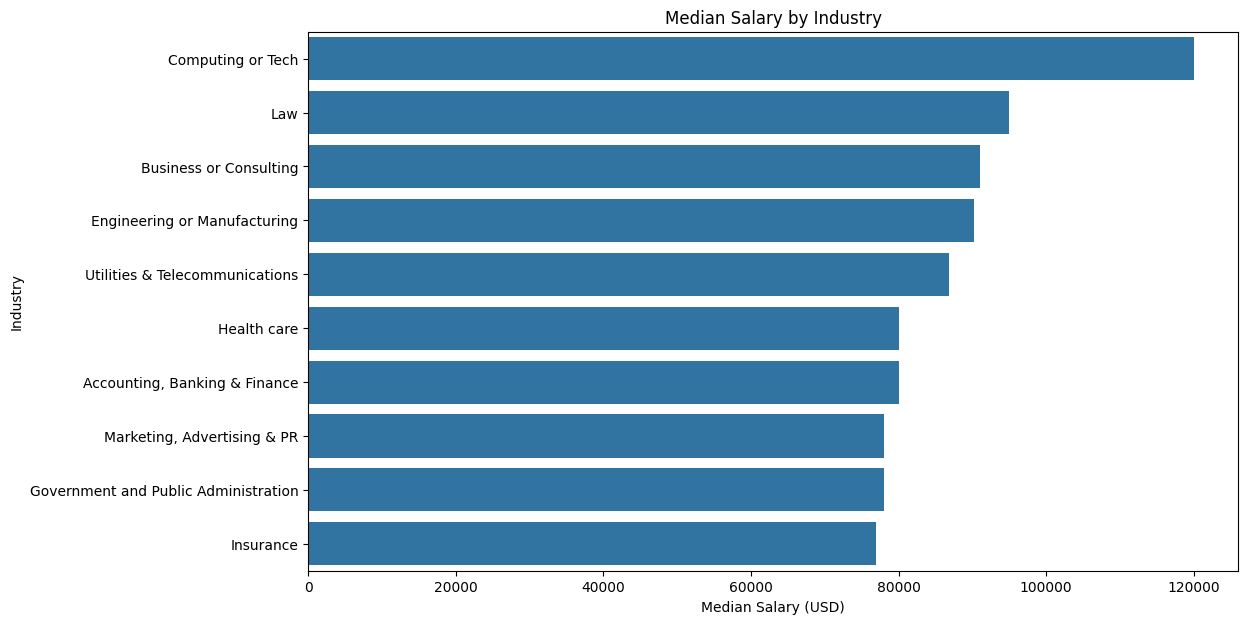

In [143]:
top_industries = industry_stats.head(10).reset_index()
plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_industries,
    x='median_salary',
    y='Industry' # Changed 'industry' to 'Industry'
)
plt.title('Median Salary by Industry')
plt.xlabel('Median Salary (USD)')
plt.ylabel('Industry')
plt.show()

In [144]:
# Question 2: How does salary increase with years of experience?
experience_stats = (
    usd_df.groupby('Overall Experience')['Salary']
    .agg(respondents='count', average_salary='mean', median_salary='median')
)

# Put the rows in natural order (least to most experience) instead of alphabetical
experience_order = list(experience_map.keys())
experience_stats = experience_stats.reindex(experience_order)

print(experience_stats)


                    respondents  average_salary  median_salary
Overall Experience                                            
1 year or less              389    68292.354756        58000.0
2 - 4 years                2378    70319.082843        61500.0
5-7 years                  3933    80901.817188        70000.0
8 - 10 years               4397   112334.991585        77000.0
11 - 20 years              8049    99590.853522        86000.0
21 - 30 years              3027   106626.729105        91000.0
31 - 40 years               725   108828.846897        90000.0
41 years or more            109    97218.422018        90000.0


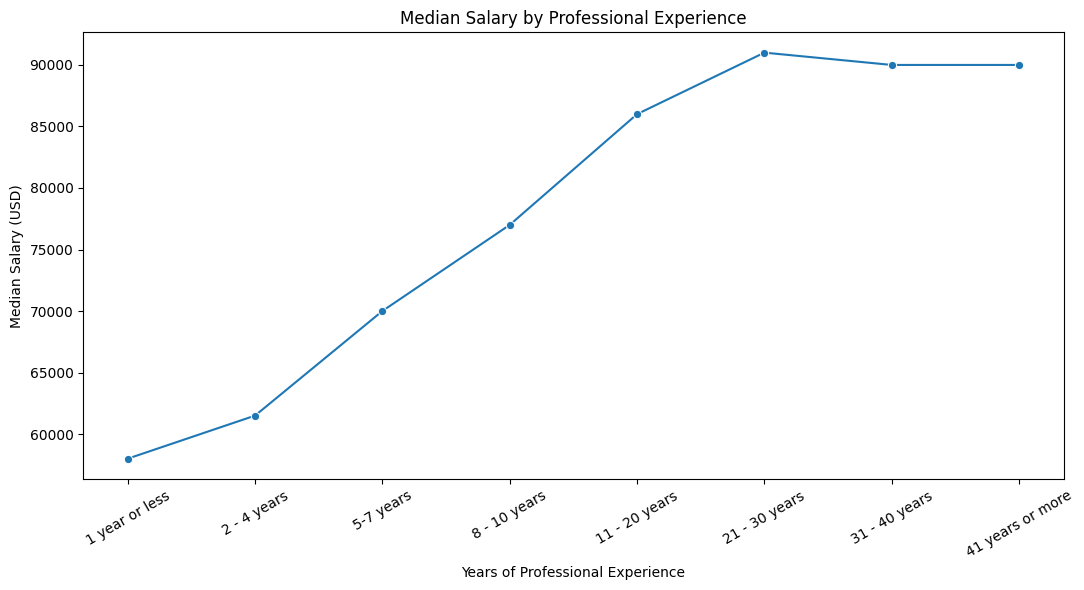

In [145]:
#Graph for question 2
#There is a clear positive relationship between experience and salary through the early and mid-career stages.
# Median salary rises from approximately $58,000 for respondents with one year or less experience to $91,000 for those with 21–30 years.
#After that, the increase largely levels off.
plt.figure(figsize=(11, 6))
sns.lineplot(
    data=experience_stats.reset_index(),
    x='Overall Experience',
    y='median_salary',
    marker='o'
)
plt.title('Median Salary by Professional Experience')
plt.xlabel('Years of Professional Experience')
plt.ylabel('Median Salary (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [146]:
#3. How do salaries compare for the same role in different location
software_engineers = usd_df[
    (usd_df['Job Title'].str.strip().str.lower() == 'software engineer') &
    (usd_df['Country Clean'] == 'United states') # Corrected 'United States' to 'United states'
].copy()

In [147]:
# This calculates salary statistics for 'Software Engineer' roles in different states within the United States.
state_salary = (
    software_engineers
    .groupby('State')['Salary']
    .agg(
        respondents='count',
        median_salary='median',
        average_salary='mean'
    )
    .query('respondents >= 10')
    .sort_values('median_salary', ascending=False)
)
state_salary

,respondents,median_salary,average_salary
State,,,


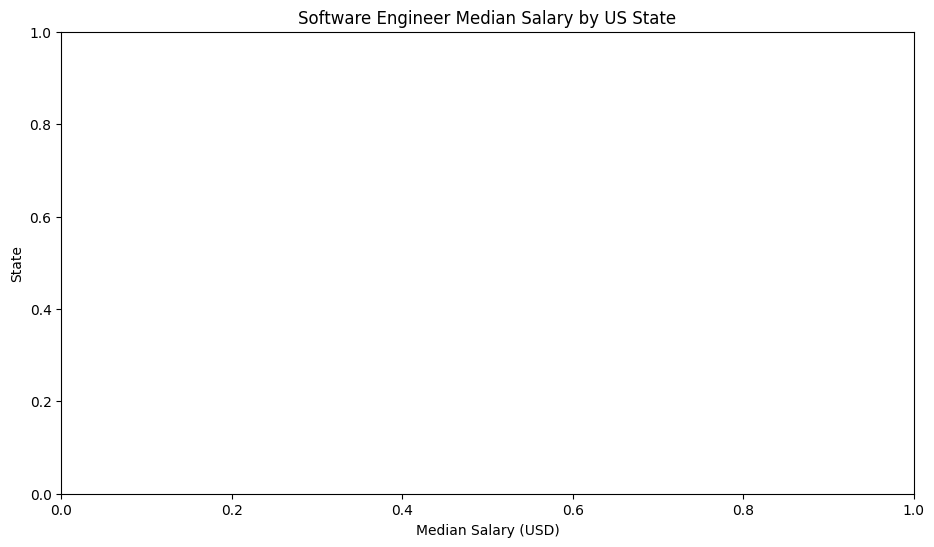

In [148]:
#Graph for question 3
#Among states with at least 10 Software Engineer respondents, New York has the highest median reported salary at $155,500,
#followed by California at $147,000.
#Be careful to say this is an association in the survey data, not proof that location causes the difference.

plot_data = state_salary.reset_index()
plt.figure(figsize=(11, 6))
sns.barplot(
    data=plot_data,
    x='median_salary',
    y='State' # Changed 'state' to 'State'
)
plt.title('Software Engineer Median Salary by US State')
plt.xlabel('Median Salary (USD)')
plt.ylabel('State')
plt.show()

In [149]:
#4. How much do salaries differ by age and years of experience
gender_exp = (
    usd_df[
        usd_df['Gender'].isin(['Man', 'Woman']) # Changed 'gender' to 'Gender'
    ]
    .groupby(['Gender', 'Overall Experience'])['Salary'] # Changed 'gender' to 'Gender' and 'overall_experience' to 'Overall Experience' and 'salary' to 'Salary'
    .median()
    .reset_index()
)

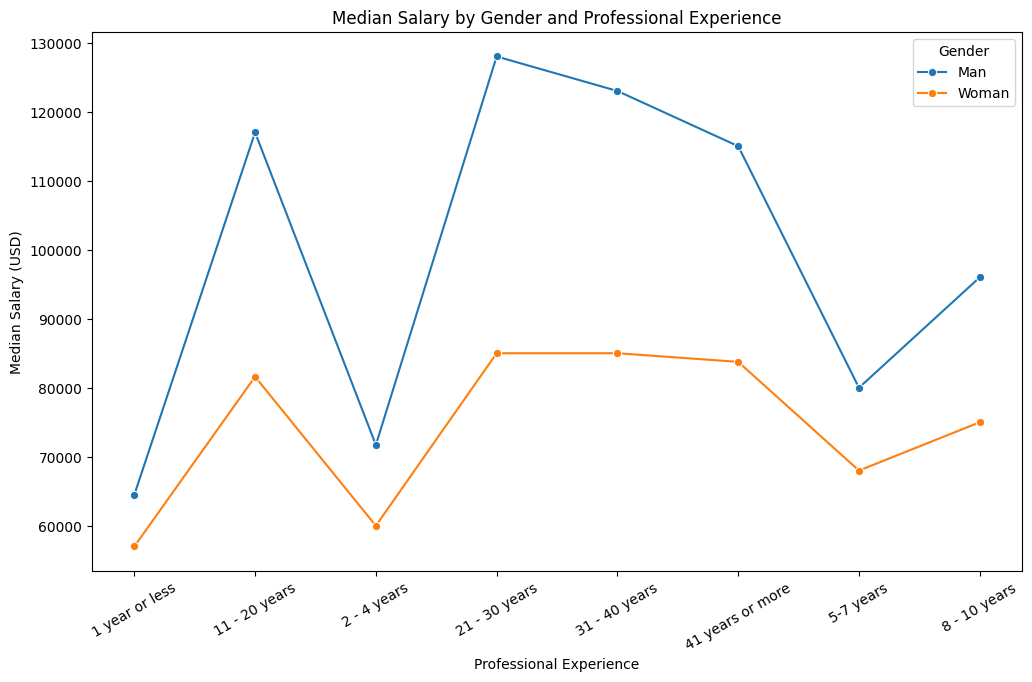

In [150]:
#Graph for question 4
#The survey shows a substantial gender salary gap at most experience levels.
#The difference becomes particularly large in the 11–30 year experience ranges.
#Again, phrase this as an observed association rather than saying gender itself causes the salary difference.
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=gender_exp,
    x='Overall Experience', # Changed 'overall_experience' to 'Overall Experience'
    y='Salary', # Changed 'salary' to 'Salary'
    hue='Gender', # Changed 'gender' to 'Gender'
    marker='o'
)
plt.title('Median Salary by Gender and Professional Experience')
plt.xlabel('Professional Experience')
plt.ylabel('Median Salary (USD)')
plt.xticks(rotation=30)
plt.show()

In [151]:
#5.How do factors like race and education level correlate with salary?
#Grouping salary by education
education_stats = (
    usd_df.groupby('Education')['Salary']
    .agg(
        respondents='count',
        median_salary='median'
    )
    .sort_values('median_salary', ascending=False)
)
education_stats

,respondents,median_salary
Education,,
Professional degree,1131,120000.0
PhD,1121,97000.0
Master's degree,7433,80000.0
None,148,76000.0
College degree,11156,75000.0
Some college,1613,63000.0
High School,405,56000.0


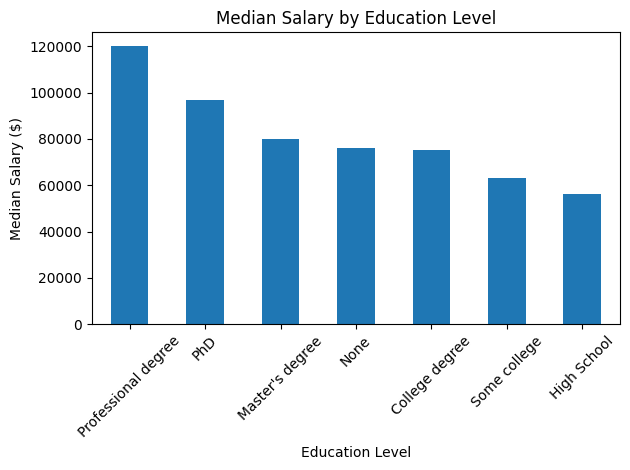

In [152]:
#Graph for question 5
import matplotlib.pyplot as plt
education_stats['median_salary'].plot(kind='bar')
plt.title('Median Salary by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Median Salary ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [153]:
race_patterns = {
    'White': r'\bWhite\b',
    'Asian or Asian American': r'Asian or Asian American',
    'Black or African American': r'Black or African American',
    'Hispanic, Latino, or Spanish origin': r'Hispanic, Latino, or Spanish origin',
    'Middle Eastern or Northern African': r'Middle Eastern or Northern African',
    'Native American or Alaska Native': r'Native American or Alaska Native',
    'Another option not listed here or prefer not to answer':
        r'Another option not listed here or prefer not to answer'
}

In [154]:
import re
#Race record
race_records = []
for _, row in usd_df.dropna(subset=['Race']).iterrows():
    race_value = str(row['Race'])

    for category, pattern in race_patterns.items():
        if re.search(pattern, race_value):
            race_records.append({
                'race': category,
                'salary': row['Salary']
            })
race_df = pd.DataFrame(race_records)

In [155]:
#Because respondents can select multiple categories, these groups are not mutually exclusive
#Group Salary by race
race_stats = (
    race_df.groupby('race')['salary']
    .agg(
        respondents='count',
        median_salary='median'
    )
    .sort_values('median_salary', ascending=False)
)
race_stats

,respondents,median_salary
race,,
Asian or Asian American,1459,92000.0
Another option not listed here or prefer not to answer,515,85280.0
Middle Eastern or Northern African,148,80000.0
Black or African American,766,79000.0
Native American or Alaska Native,122,78500.0
White,20035,77000.0
"Hispanic, Latino, or Spanish origin",979,75000.0


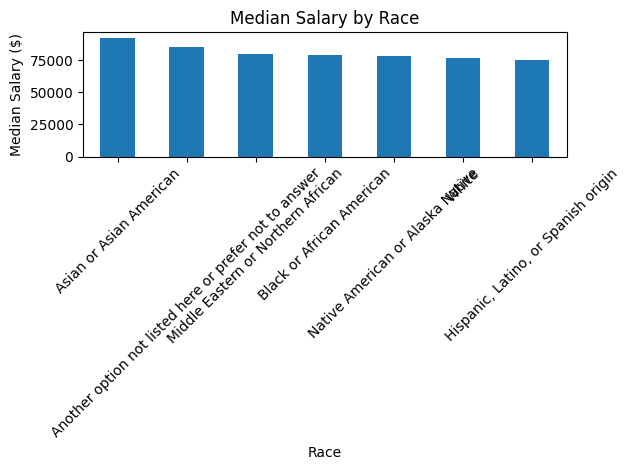

In [156]:
#Graph for salary by race
race_stats['median_salary'].plot(kind='bar')
plt.title('Median Salary by Race')
plt.xlabel('Race')
plt.ylabel('Median Salary ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [157]:
#6. Is there a "sweet spot" between total work experience and years in the specific field — i.e.
# does having more years in-role beyond overall experience relate differently to salary than the reverse?

#Create your derived feature
usd_df['overall_exp_midpoint'] = (
    usd_df['Overall Experience'].map(experience_map)
)

usd_df['field_exp_midpoint'] = (
    usd_df['Field Experience'].map(experience_map)
)

In [158]:
#This calculates the experience gap by substracting field_exp_midpoint from overall_exp_midpoint
usd_df['experience_gap'] = (
    usd_df['overall_exp_midpoint'] -
    usd_df['field_exp_midpoint']
)

In [159]:
#Creating a datframe called q6 to filter usd_df to include only respondents where the age gap is >=0
q6 = usd_df[
    usd_df['experience_gap'] >= 0
].copy()

In [160]:
#Categorizing the age gap
bins = [-0.1, 0.1, 5.5, 10.1, 100]

labels = [
    '0 years',
    '2.5–5.5 years',
    '6–10 years',
    '11+ years'
]
q6['gap_group'] = pd.cut(
    q6['experience_gap'],
    bins=bins,
    labels=labels
)

In [161]:
bins = [-0.1, 0.1, 5.5, 10.1, 100]
labels = [
    '0 years',
    '2.5–5.5 years',
    '6–10 years',
    '11+ years'
]
q6['gap_group'] = pd.cut(
    q6['experience_gap'],
    bins=bins,
    labels=labels
)

/tmp/ipykernel_7137/2344932257.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q6.groupby('gap_group')['Salary']


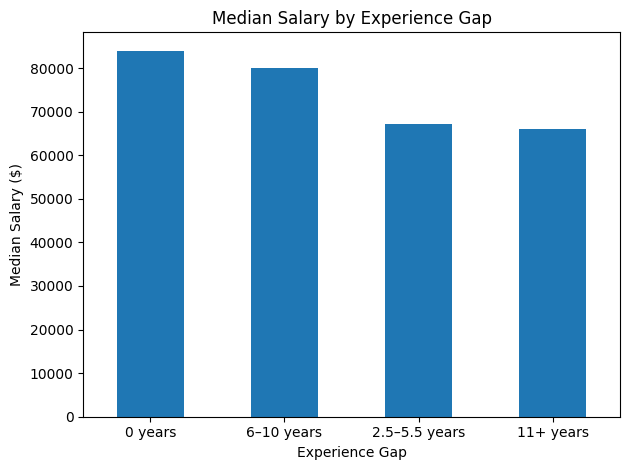

In [162]:
#Graph for Question 6
import matplotlib.pyplot as plt

gap_stats = (
    q6.groupby('gap_group')['Salary']
    .agg(
        respondents='count',
        median_salary='median'
    )
    .sort_values('median_salary', ascending=False)
)

gap_stats['median_salary'].plot(kind='bar')
plt.title('Median Salary by Experience Gap')
plt.xlabel('Experience Gap')
plt.ylabel('Median Salary ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [163]:
#The survey does not show a simple "more experience outside your current field = higher salary" pattern.
#The highest median salary occurs among respondents whose total experience and field experience are approximately aligned, at $84,000.
#The 2.5–5.5 and 11+ year gaps have noticeably lower medians.
# You can therefore say that the data does not provide strong evidence of a salary sweet spot where having substantially more experience outside the current field improves salary.

In [164]:
#Question	Main finding
#1. Highest-paying industry	Computing/Tech — median $120k
#2. Experience vs salary	Salary rises with experience, particularly through 21–30 years
#3. Same role/location	Software Engineers in New York have the highest median among tested states — $155.5k
#4. Gender + experience	Men report higher median salaries than women across the major experience groups
#5. Race + education	Professional degrees and PhDs have higher median salaries; race groups also show differences
#6. Experience gap	Largest median occurs when overall and field experience are approximately aligned; no clear "sweet spot" from a large experience gap